# **All the required libraries**

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score





## **Loading the data and data overview**

In [ ]:
df= pd.read_csv('insurance.csv')

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


observation:  age, bmi, children are evenly distributed. charge appears right-skewed. some individual with highers charges pull the mean upward, while the majority is lower

In [ ]:
df.info()

df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#  finding if there is any duplicate
df.duplicated().sum()

np.int64(1)

In [ ]:
#finding if there is any null values and compute the percentage
df.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# **Exploratory Motivation of the dataset**

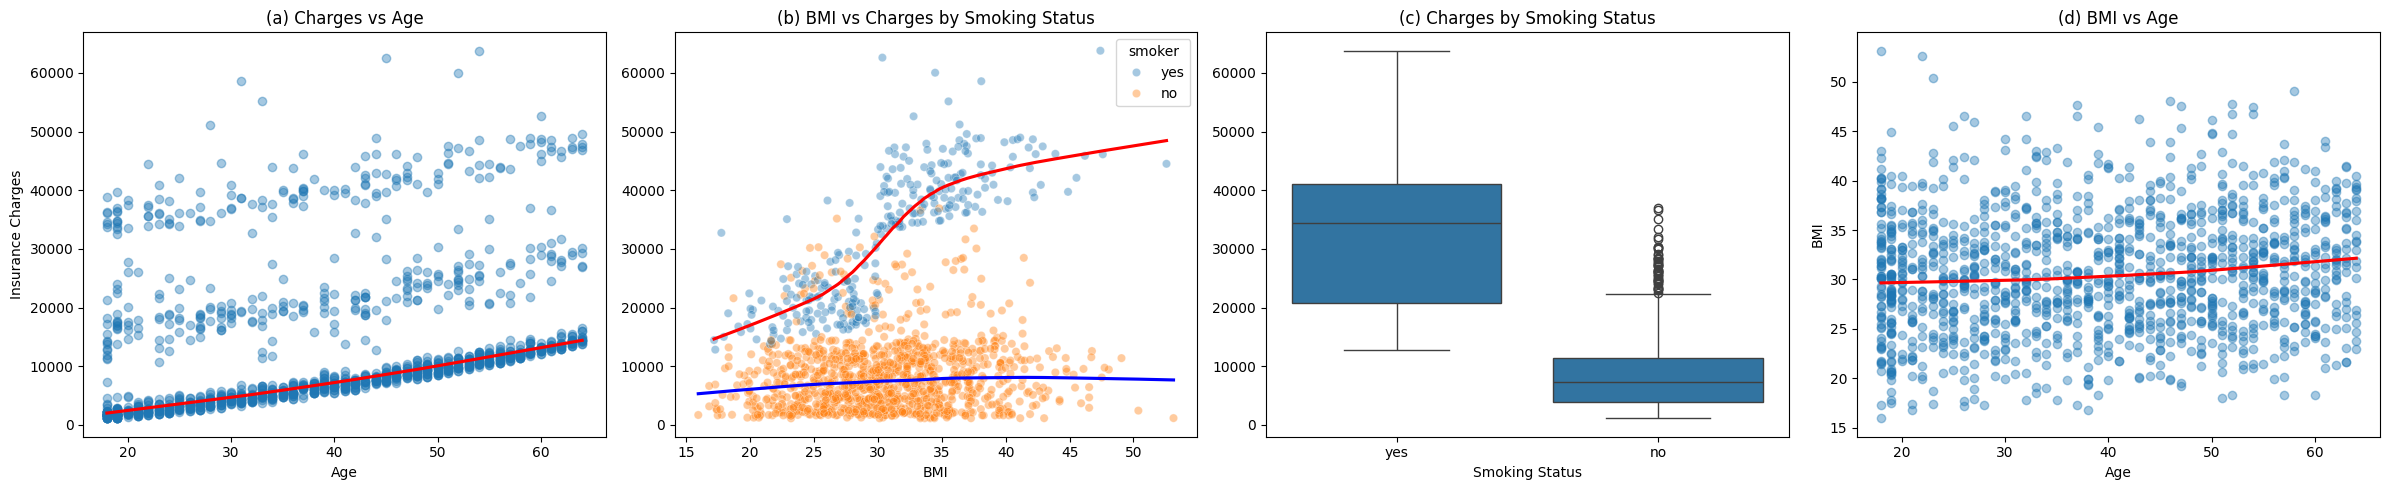

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(24, 5)) #

# ----- Panel (a): Age vs Charges -----
sns.regplot(
    x="age",
    y="charges",
    data=df,
    lowess=True,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("(a) Charges vs Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Insurance Charges")

# ----- Panel (b): BMI vs Charges by Smoking Status -----
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=df,
    alpha=0.4,
    ax=axes[1]
)

sns.regplot(
    x="bmi",
    y="charges",
    data=df[df["smoker"] == "yes"],
    lowess=True,
    scatter=False,
    color="red",
    ax=axes[1]
)

sns.regplot(
    x="bmi",
    y="charges",
    data=df[df["smoker"] == "no"],
    lowess=True,
    scatter=False,
    color="blue",
    ax=axes[1]
)

axes[1].set_title("(b) BMI vs Charges by Smoking Status")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("")

# ----- Panel (c): Smoking Status vs Charges -----
sns.boxplot(
    x="smoker",
    y="charges",
    data=df,
    ax=axes[2]
)
axes[2].set_title("(c) Charges by Smoking Status")
axes[2].set_xlabel("Smoking Status")
axes[2].set_ylabel("")



# ----- Panel (d): Age vs BMI -----
sns.regplot(
    x="age",
    y="bmi", # Corrected column name from 'BMI' to 'bmi'
    data=df,
    lowess=True,
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"},
    ax=axes[3] # Correctly passing the axis to regplot
)
axes[3].set_title("(d) BMI vs Age")
axes[3].set_xlabel("Age")
axes[3].set_ylabel("BMI")

plt.tight_layout()
plt.show()

In [ ]:



# ============================================================
# Encode Categorical Variables
# ============================================================


# One-hot encode categorical predictors
df_encoded = pd.get_dummies(df, drop_first=True)

# Define predictors and target
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 3. Feature Scaling
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 4. Baseline Linear Regression Model
# ============================================================

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)
residuals_linear = y_test - y_pred_linear

linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

# ============================================================
# 5. Non-Linear Model 1: Polynomial Regression (Degree 2)
# ============================================================

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)
residuals_poly = y_test - y_pred_poly

poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_r2 = r2_score(y_test, y_pred_poly)

# ============================================================
# 6. Non-Linear Model 2: Interaction Model (BMI × Smoking)
# ============================================================

X_interaction = X.copy()
X_interaction["bmi_smoker"] = X_interaction["bmi"] * X_interaction["smoker_yes"]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interaction, y, test_size=0.2, random_state=42
)

X_train_i_scaled = scaler.fit_transform(X_train_i)
X_test_i_scaled = scaler.transform(X_test_i)

interaction_model = LinearRegression()
interaction_model.fit(X_train_i_scaled, y_train_i)

y_pred_interaction = interaction_model.predict(X_test_i_scaled)
residuals_interaction = y_test_i - y_pred_interaction

interaction_rmse = np.sqrt(mean_squared_error(y_test_i, y_pred_interaction))
interaction_r2 = r2_score(y_test_i, y_pred_interaction)

# ============================================================
# 7. Side-by-Side Residual Diagnostics
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Linear model residuals
axes[0].scatter(y_pred_linear, residuals_linear, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Predicted Charges")
axes[0].set_ylabel("Residuals")

# Polynomial regression residuals
axes[1].scatter(y_pred_poly, residuals_poly, alpha=0.4)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Polynomial Regression (Degree 2)")
axes[1].set_xlabel("Predicted Charges")

# Interaction model residuals
axes[2].scatter(y_pred_interaction, residuals_interaction, alpha=0.4)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Interaction Model (BMI × Smoker)")
axes[2].set_xlabel("Predicted Charges")

plt.suptitle("Residual Diagnostics Across Models", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 8. Model Performance Comparison
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression (Degree 2)",
        "Interaction Regression (BMI × Smoker)"
    ],
    "RMSE": [
        linear_rmse,
        poly_rmse,
        interaction_rmse
    ],
    "R2": [
        linear_r2,
        poly_r2,
        interaction_r2
    ]
})

print(results)


# Additional Test: Testing the polynomial with  degree 1,2,3 to see if there is improvement

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# ============================================================
# 5. Non-Linear Model 1: Polynomial Regression with degree 1,2,3
# ============================================================

polynomial_results = []

for degree in range(1, 4): # Iterating for degrees 1, 2, and 3
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly_current = poly.fit_transform(X_train_scaled)
    X_test_poly_current = poly.transform(X_test_scaled)

    poly_model_current = LinearRegression()
    poly_model_current.fit(X_train_poly_current, y_train)

    y_pred_poly = poly_model_current.predict(X_test_poly_current) # Update for plotting the last degree
    residuals_poly = y_test - y_pred_poly # Update for plotting the last degree

    current_poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    current_poly_r2 = r2_score(y_test, y_pred_poly)

    polynomial_results.append({
        "Model": f"Polynomial Regression (Degree {degree})",
        "RMSE": current_poly_rmse,
        "R2": current_poly_r2
    })

# ============================================================
# 6. Non-Linear Model 2: Interaction Model (BMI × Smoking)
# ============================================================

X_interaction = X.copy()
X_interaction["bmi_smoker"] = X_interaction["bmi"] * X_interaction["smoker_yes"]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interaction, y, test_size=0.2, random_state=42
)

X_train_i_scaled = scaler.fit_transform(X_train_i)
X_test_i_scaled = scaler.transform(X_test_i)

interaction_model = LinearRegression()
interaction_model.fit(X_train_i_scaled, y_train_i)

y_pred_interaction = interaction_model.predict(X_test_i_scaled)
residuals_interaction = y_test_i - y_pred_interaction

interaction_rmse = np.sqrt(mean_squared_error(y_test_i, y_pred_interaction))
interaction_r2 = r2_score(y_test_i, y_pred_interaction)

# ============================================================
# 7. Side-by-Side Residual Diagnostics
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Linear model residuals
axes[0].scatter(y_pred_linear, residuals_linear, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Predicted Charges")
axes[0].set_ylabel("Residuals")

# Polynomial regression residuals (will show for the last computed degree, i.e., Degree 3)
axes[1].scatter(y_pred_poly, residuals_poly, alpha=0.4)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Polynomial Regression (Degree 3)") # Updated title
axes[1].set_xlabel("Predicted Charges")

# Interaction model residuals
axes[2].scatter(y_pred_interaction, residuals_interaction, alpha=0.4)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Interaction Model (BMI × Smoker)")
axes[2].set_xlabel("Predicted Charges")

plt.suptitle("Residual Diagnostics Across Models", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 8. Model Performance Comparison
# ============================================================

# Combine all results
all_results_data = [
    {
        "Model": "Linear Regression",
        "RMSE": linear_rmse,
        "R2": linear_r2
    }
]
all_results_data.extend(polynomial_results) # Add all polynomial degrees
all_results_data.append(
    {
        "Model": "Interaction Regression (BMI × Smoker)",
        "RMSE": interaction_rmse,
        "R2": interaction_r2
    }
)

results = pd.DataFrame(all_results_data)

print(results)


Degree 2 is the best